In [13]:
import math

import numpy as np
import matplotlib.pyplot as plt

In [50]:
class LinearSTDScheduler:
    def __init__(self, start_factor: float, end_factor: float, total_steps: int):
        self.start_factor = start_factor
        self.end_factor = end_factor
        self.total_steps = total_steps

    def get_std(self):
        t = min(self.last_step / self.total_steps, 1.0)
        return self.start_factor + t * (self.end_factor - self.start_factor)
    
class CosineSTDScheduler:
    def __init__(self, start_factor: float, end_factor: float, total_steps: int):
        self.start_factor = start_factor
        self.end_factor = end_factor
        self.total_steps = total_steps

    def get_std(self):
        t = min(self.last_step / self.total_steps, 1.0)
        cos_t = 0.5 * (1 + math.cos(math.pi * t))
        return self.end_factor + (self.start_factor - self.end_factor) * cos_t
    
class ConstantSTDScheduler:
    def __init__(self, start_factor: float, total_steps: int, *args, **kwargs):
        self.factor = start_factor
        self.total_steps = total_steps

    def get_std(self):
        return self.factor

In [51]:
def get_samples(recurrences, std_values):
    output = [] 
    for std in std_values:
        samples = [recurrences + np.random.normal(0, std*recurrences/2) for _ in range(10)]
        samples = [max(1, sample) for sample in samples]
        samples = [min(2*recurrences, sample) for sample in samples]
        output.append(np.mean(samples))
    return output

In [52]:
total_steps = 2000
scheduler = ConstantSTDScheduler(start_factor=1.0, end_factor=0.1, total_steps=total_steps)
std_values = []
for step in range(total_steps+1):
    scheduler.last_step = step
    std_values.append(scheduler.get_std())

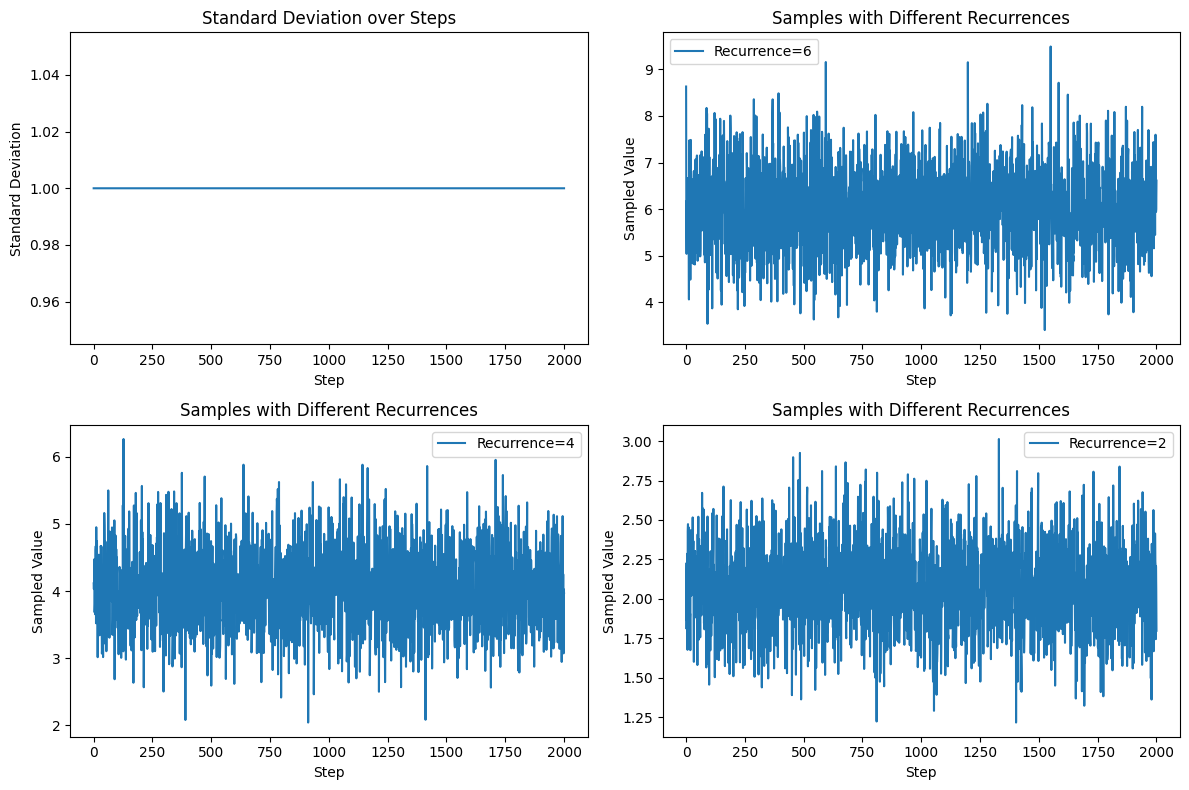

In [53]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
ax[0].plot(std_values)
ax[0].set_title('Standard Deviation over Steps')
ax[0].set_xlabel('Step')
ax[0].set_ylabel('Standard Deviation')


ax[1].plot(get_samples(6, std_values), label='Recurrence=6')
ax[2].plot(get_samples(4, std_values), label='Recurrence=4')
ax[3].plot(get_samples(2, std_values), label='Recurrence=2')

for i in range(1, 4):
    ax[i].set_title(f'Samples with Different Recurrences')
    ax[i].set_xlabel('Step')
    ax[i].set_ylabel('Sampled Value')
    ax[i].legend()

plt.tight_layout()